# Week 3 - Lab Exercise
## Exercise 1 (BFS)

In [332]:
# Libraries Importing
from collections import deque
import time
import networkx as nx
import matplotlib.pyplot as plt

In [333]:
def bfs(graph, start, goal):
    visited = set()
    queue = deque([(start, [])])
    while queue:
        node, path = queue.popleft()
        if node == goal:
            return path + [node]
        if node not in visited:
            visited.add(node)
            for neighbor in graph[node]:
                queue.append((neighbor, path + [node]))
    return None # Goal not found

# Edited graph 1 to same as Fig 1
graph_1 = {
'A': ['B', 'C'],
'B': ['D', 'E'],
'C': ['F'],
'D': [],
'E': [],
'F': ['E']
}

start_node = 'A'
goal_node = 'E'
result = bfs(graph_1, start_node, goal_node)
if result:
    print("Path found:", result)
else:
    print("No path found.")

Path found: ['A', 'B', 'E']


#### Q1: Change the starting and ending point and observe the problem solution.

In [334]:
result = bfs(graph_1, "A", "F")
if result:
    print("Path found:", result)
else:
    print("No path found.")

Path found: ['A', 'C', 'F']


#### Q2: Use the time library to calculate how long would it take to solve the problem using three different starting points and ending points

In [335]:
search_data = [
  {"start_node": "A", "goal_node": "E"},
  {"start_node": "C", "goal_node": "F"},
  {"start_node": "B", "goal_node": "E"},
  {"start_node": "D", "goal_node": "F"}  
]

for search in search_data:
  start_node = search["start_node"]
  goal_node = search["goal_node"]
  start_time = time.process_time()
  result = bfs(graph_1, start_node, goal_node)
  end_time = time.process_time()
    
  if result:
    print(f"Path found for {start_node} to {goal_node}:", result)
  else:
    print(f"No path found for {start_node} to {goal_node}.")

  print (f"Total searching time: {(end_time - start_time) * 10**3} ms \n")

Path found for A to E: ['A', 'B', 'E']
Total searching time: 0.0 ms 

Path found for C to F: ['C', 'F']
Total searching time: 0.0 ms 

Path found for B to E: ['B', 'E']
Total searching time: 0.0 ms 

No path found for D to F.
Total searching time: 0.0 ms 



#### Q3: Change the script to mode the following graph:

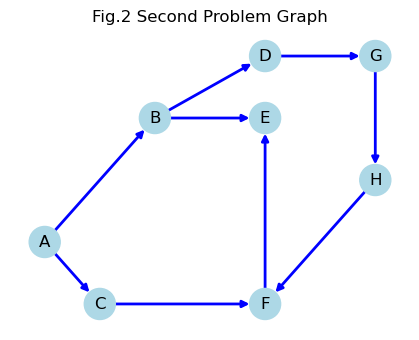

In [336]:
# Define the new graph
graph_2 = {
'A': ['B', 'C'],
'B': ['D', 'E'],
'C': ['F'],
'D': ['G'],
'E': [],
'F': ['E'],
'G': ['H'],
'H': ['F']
}

# Define node positions
node_positions = {
    'A': (2.5, 2),
    'B': (3.5, 3),
    'C': (3, 1.5),
    'D': (4.5, 3.5),
    'E': (4.5, 3),
    'F': (4.5, 1.5),
    'G': (5.5, 3.5),
    'H': (5.5, 2.5)  
}

# Create a NetworkX graph object from the dictionary
G = nx.DiGraph(graph_2)
node_colors = ['lightblue' for node in G]  # Use the iterable directly
node_sizes = [500 for _ in G]  # Create a list with the same length as nodes
edge_colors = 'blue'
edge_widths = 2

# Create the visual representation using networkx.draw
plt.figure(figsize=(4, 3))  # Adjust figure size as needed

nx.draw(
    G,
    pos=node_positions,  # Use the defined node positions
    with_labels=True,  # Show node labels
    node_color=node_colors,
    node_size=node_sizes,
    edge_color=edge_colors,
    width=edge_widths
)

plt.title("Fig.2 Second Problem Graph", fontsize=12)
plt.axis('off')  # Hide axes
plt.show()

#### Q4: Update the script to find the solution of the problem and experiment with different starting points, e.g., start from A and end at H

In [337]:
search_data = [
  {"start_node": "A", "goal_node": "H"},
  {"start_node": "B", "goal_node": "E"},
  {"start_node": "C", "goal_node": "D"},
  {"start_node": "D", "goal_node": "E"},
  {"start_node": "E", "goal_node": "H"},
  {"start_node": "F", "goal_node": "A"},
  {"start_node": "G", "goal_node": "E"},
  {"start_node": "H", "goal_node": "E"}
]

for search in search_data:
  start_node = search["start_node"]
  goal_node = search["goal_node"]
  start_time = time.process_time()
  result = bfs(graph_2, start_node, goal_node)
  end_time = time.process_time()
    
  if result:
    print(f"Path found for {start_node} to {goal_node}:", result)
  else:
    print(f"No path found for {start_node} to {goal_node}.")

  print (f"Total searching time: {(end_time - start_time) * 10**3} ms \n")

Path found for A to H: ['A', 'B', 'D', 'G', 'H']
Total searching time: 0.0 ms 

Path found for B to E: ['B', 'E']
Total searching time: 0.0 ms 

No path found for C to D.
Total searching time: 0.0 ms 

Path found for D to E: ['D', 'G', 'H', 'F', 'E']
Total searching time: 0.0 ms 

No path found for E to H.
Total searching time: 0.0 ms 

No path found for F to A.
Total searching time: 0.0 ms 

Path found for G to E: ['G', 'H', 'F', 'E']
Total searching time: 0.0 ms 

Path found for H to E: ['H', 'F', 'E']
Total searching time: 0.0 ms 



## Exercise 2 (DFS)

In [338]:
# Copied the script and compared the time to find the solution using both algorithms and graphs.
def dfs(graph, node, goal, visited=None):
    if visited is None:
        visited = set()
    if node == goal:
        return [node]
    if node not in visited:
        visited.add(node)
        for neighbor in graph[node]:
            path = dfs(graph, neighbor, goal, visited)
            if path:
                return [node] + path
    return None # Goal not found

def choose_search_method(search_method):
  """
  Selects the search function (DFS or BFS) based on the method name.

  Args:
      search_method (str): The search method name ("dfs" or "bfs").

  Returns:
      function: The chosen search function (dfs or bfs).
  """
  if search_method == "dfs":
    return dfs
  elif search_method == "bfs":
    return bfs
  elif search_method == "lds":
    return lds
  else:
    raise ValueError(f"Invalid search method: {search_method}")

# Methods to run
methods = ["dfs", "bfs"]

search_data = [
  {"start_node": "A", "goal_node": "E"},
  {"start_node": "A", "goal_node": "H"},
]

for graph in [graph_1, graph_2]:
  # Identify graph number (1 or 2)
  graph_number = [i + 1 for i, g in enumerate([graph_1, graph_2]) if g == graph][0]

  for method in methods:
    # Choose search function
    search_function = choose_search_method(method)

    # Execute the search with modified start/goal nodes for each graph

    for search in search_data:
      start_node = search["start_node"]
      goal_node = search["goal_node"]
        
      start_time = time.process_time()
      result = search_function(graph, start_node, goal_node)
      end_time = time.process_time()

      print(f"Search Path: {start_node} to {goal_node} "
            f"using Method: {method} on Graph: {graph_number}")
        
      if result:
        print(f"Path found for :", result)
      else:
        print(f"No path found.")
      
      print (f"Total searching time: {(end_time - start_time) * 10**3} ms \n")
      

Search Path: A to E using Method: dfs on Graph: 1
Path found for : ['A', 'B', 'E']
Total searching time: 0.0 ms 

Search Path: A to H using Method: dfs on Graph: 1
No path found.
Total searching time: 0.0 ms 

Search Path: A to E using Method: bfs on Graph: 1
Path found for : ['A', 'B', 'E']
Total searching time: 0.0 ms 

Search Path: A to H using Method: bfs on Graph: 1
No path found.
Total searching time: 0.0 ms 

Search Path: A to E using Method: dfs on Graph: 2
Path found for : ['A', 'B', 'D', 'G', 'H', 'F', 'E']
Total searching time: 0.0 ms 

Search Path: A to H using Method: dfs on Graph: 2
Path found for : ['A', 'B', 'D', 'G', 'H']
Total searching time: 0.0 ms 

Search Path: A to E using Method: bfs on Graph: 2
Path found for : ['A', 'B', 'E']
Total searching time: 0.0 ms 

Search Path: A to H using Method: bfs on Graph: 2
Path found for : ['A', 'B', 'D', 'G', 'H']
Total searching time: 0.0 ms 



#### Q1: Change the starting and ending point and observe the problem solution.

In [339]:
# Example usage (same graph as before)
start_node = 'B'
goal_node = 'F'
result = dfs(graph, start_node, goal_node)

if result:
    print("Path found:", result)
else:
    print("No path found.")

Path found: ['B', 'D', 'G', 'H', 'F']


#### Q2: Use the time library to calculate how long would it take to solve the problem using three different starting points and ending points

In [340]:
search_data = [
  {"start_node": "A", "goal_node": "H"},
  {"start_node": "B", "goal_node": "F"},
  {"start_node": "A", "goal_node": "E"},
]

for search in search_data:
  start_node = search["start_node"]
  goal_node = search["goal_node"]
  start_time = time.process_time()
  result = dfs(graph_2, start_node, goal_node)
  end_time = time.process_time()
    
  if result:
    print(f"Path found for {start_node} to {goal_node}:", result)
  else:
    print(f"No path found for {start_node} to {goal_node}.")

  print (f"Total searching time: {(end_time - start_time) * 10**3} ms \n")

Path found for A to H: ['A', 'B', 'D', 'G', 'H']
Total searching time: 0.0 ms 

Path found for B to F: ['B', 'D', 'G', 'H', 'F']
Total searching time: 0.0 ms 

Path found for A to E: ['A', 'B', 'D', 'G', 'H', 'F', 'E']
Total searching time: 0.0 ms 



## Exercise 3 (LDS)

In [341]:
def lds(graph, node, goal, depth, visited=None, found=None):
    if visited is None:
        visited = set()
    if found is None:
        found = [False]  # Use a list to allow modifications within recursive calls

    if depth == 0 or found[0]:
        return None
    if node == goal:
        found[0] = True  # Indicate that the goal has been found
        return [node]
    if node not in visited:
        visited.add(node)
        for neighbor in graph[node]:
            path = lds(graph, neighbor, goal, depth - 1, visited, found)
            if path:
                return [node] + path
    return None

start_node = 'A'
goal_node = 'E'
max_depth = 3

result = lds(graph_1, start_node, goal_node, max_depth)
if result:
    print("Path found:", result)
else:
    print("No path found.")


Path found: ['A', 'B', 'E']


#### Q1: Change the max depth and find how can use break the algorithm

In [342]:
# Test with different max depths
for max_depth in range(1, 6):  # Testing depths from 1 to 5
    result = lds(graph_1, "A", "E", max_depth)
    print(f"Max depth {max_depth}:")
    if result:
        print("Path found:", result)
    else:
        print("No path found.")
    print()

Max depth 1:
No path found.

Max depth 2:
No path found.

Max depth 3:
Path found: ['A', 'B', 'E']

Max depth 4:
Path found: ['A', 'B', 'E']

Max depth 5:
Path found: ['A', 'B', 'E']



#### Q: Make your own graph that has many many layers and do a comparing of the different algorithms

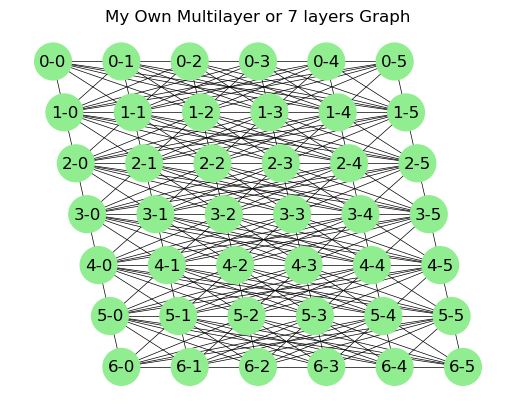

In [343]:
def generate_layered_graph(num_layers, nodes_per_layer):
  """
  Generates a directed acyclic graph (DAG) with specified number of layers and nodes per layer,
  and assigns static positions to the nodes.

  Args:
      num_layers: The number of layers in the graph.
      nodes_per_layer: The number of nodes per layer in the graph.

  Returns:
      A dictionary representing the graph structure with node positions.
  """
  multi_graph = {}
  node_positions = {}  # Dictionary to store node positions

  # Custom coordinates
  for layer in range(num_layers):
    x_base = layer * 2  # Adjust x-base for horizontal spacing between layers
    y_base = 10 - layer  # Adjust y-base for vertical spacing within layers
    for i in range(nodes_per_layer):
      node_name = f"{layer}-{i}"
      x_pos = x_base + i * 12  # Adjust spacing between nodes within a layer
      y_pos = y_base
      node_positions[node_name] = (x_pos, y_pos)

  for layer in range(num_layers):
    nodes = [f"{layer}-{i}" for i in range(nodes_per_layer)]
    multi_graph.update({node: [] for node in nodes})  # Initialize empty neighbors

    # Connect nodes within the current layer (optional, comment out for a tree structure)
    for i in range(nodes_per_layer - 1):
      multi_graph[nodes[i]].append(nodes[i + 1])

    # Connect nodes to the next layer (if not the last layer)
    if layer < num_layers - 1:
      for i in range(nodes_per_layer):
        next_layer_nodes = [f"{layer + 1}-{j}" for j in range(nodes_per_layer)]
        multi_graph[nodes[i]].extend(next_layer_nodes)  # Connect to all nodes in the next layer

  return multi_graph, node_positions

num_layers = 7
nodes_per_layer = 6
multi_graph, node_positions = generate_layered_graph(num_layers, nodes_per_layer)

G = nx.from_dict_of_lists(multi_graph)
pos = node_positions  # Use the defined node positions
node_colors = ['lightgreen' for node in G]  # Use the iterable directly
node_sizes = [700 for _ in G]  # Create a list with the same length as nodes
edge_colors = 'black'
edge_widths = 0.5

plt.title("My Own Multilayer or 7 layers Graph", fontsize=12)
nx.draw(
    G,
    pos=pos,  # Use the defined node positions
    with_labels=True,  # Show node labels
    node_color=node_colors,
    node_size=node_sizes,
    edge_color=edge_colors,
    width=edge_widths
)
plt.show()

In [344]:
""" Comparision """

start_node = "0-0"
goal_node = "6-5"
max_depth = 32

# Methods to run
methods = ["dfs", "bfs", "lds"]

for method in methods:
    search_function = choose_search_method(method)
        
    start_time = time.process_time()
    if (method == "lds"):
        result = lds(multi_graph, start_node, goal_node, max_depth)
    else: 
        result = search_function(multi_graph, start_node, goal_node)
    end_time = time.process_time()

    print(f"Search Path: {start_node} to {goal_node} "
        f"using Method: {method}")
        
    if result:
        print(f"Path found for :", result)
    else:
        print(f"No path found.")
      
    print (f"Total searching time: {(end_time - start_time) * 10**3} ms \n")


Search Path: 0-0 to 6-5 using Method: dfs
Path found for : ['0-0', '0-1', '0-2', '0-3', '0-4', '0-5', '1-0', '1-1', '1-2', '1-3', '1-4', '1-5', '2-0', '2-1', '2-2', '2-3', '2-4', '2-5', '3-0', '3-1', '3-2', '3-3', '3-4', '3-5', '4-0', '4-1', '4-2', '4-3', '4-4', '4-5', '5-0', '5-1', '5-2', '5-3', '5-4', '5-5', '6-0', '6-1', '6-2', '6-3', '6-4', '6-5']
Total searching time: 0.0 ms 

Search Path: 0-0 to 6-5 using Method: bfs
Path found for : ['0-0', '1-0', '2-0', '3-0', '4-0', '5-0', '6-5']
Total searching time: 0.0 ms 

Search Path: 0-0 to 6-5 using Method: lds
Path found for : ['0-0', '0-1', '0-2', '0-3', '0-4', '0-5', '1-0', '1-1', '1-2', '1-3', '1-4', '1-5', '2-0', '2-1', '2-2', '2-3', '2-4', '2-5', '3-0', '3-1', '3-2', '3-3', '3-4', '3-5', '4-0', '4-1', '4-2', '4-3', '4-4', '4-5', '5-0', '6-5']
Total searching time: 0.0 ms 



## Exercise 4 (BFS Maze)

In [345]:
from collections import deque

def bfs_maze(maze, start, goal):
    rows, cols = len(maze), len(maze[0])
    visited = set()
    parent = {} # To keep track of the parent of each cell in the path

    def is_valid(x, y):
        return 0 <= x < rows and 0 <= y < cols and maze[x][y] != '#' and (x, y) not in visited

    queue = deque([start])
    visited.add(start)
    found = False

    while queue:
        x, y = queue.popleft()
        if (x, y) == goal: found = True; break
        # Define possible moves: up, down, left, right
        moves = [(0, 1), (1, 0), (0, -1), (-1, 0)]
    
        for dx, dy in moves:
            new_x, new_y = x + dx, y + dy
            if is_valid(new_x, new_y):
                queue.append((new_x, new_y))
                visited.add((new_x, new_y))
                parent[(new_x, new_y)] = (x, y)

    if not found: return "No path found"
    
    # Reconstruct the path from the goal to the start
    path = []
    x, y = goal
    while (x, y) != start:
        path.append((x, y))
        x, y = parent[(x, y)]
        path.append(start)
        path.reverse()

    # Update the maze with the path
    for x, y in path:
        if maze[x][y] != 'S' and maze[x][y] != 'G':
            maze[x][y] = '*'
            steps = len(path) - 1 
    return f"Path found with {steps} steps"

# Define the corrected maze
maze = [
    ['S', '.', '.', '.', '.', '.', '#', '.', '.'],
    ['#', '#', '#', '#', '#', '.', '#', '#', '#'],
    ['.', '.', '.', '.', '.', '.', '.', '.', 'G'],
    ['#', '#', '#', '#', '#', '#', '#', '#', '#']
]

# Starting and goal positions
start_position = (0, 0)
goal_position = (2, 8)

bfs_maze_start = time.process_time()
result = bfs_maze(maze, start_position, goal_position)
bfs_maze_end = time.process_time()

# Print the maze with the path
for row in maze:
    print(' '.join(row))

print(result)

S * * * * * # . .
# # # # # * # # #
. . . . . * * * G
# # # # # # # # #
Path found with 19 steps


## Exercise 5 (DFS Maze)

In [346]:
from collections import deque

def dfs_maze(maze, start, goal):
    rows, cols = len(maze), len(maze[0])
    visited = set()
    path = [] # Store the path
    
    def is_valid(x, y):
        return 0 <= x < rows and 0 <= y < cols and maze[x][y] != '#' and (x, y) not in visited

    def dfs(x, y):
        if x == goal[0] and y == goal[1]:
            return True
            
        visited.add((x, y))
        path.append((x, y))

        # Define possible moves: up, down, left, right
        moves = [(0, 1), (1, 0), (0, -1), (-1, 0)]   
        for dx, dy in moves:
            new_x, new_y = x + dx, y + dy
            if is_valid(new_x, new_y):
                if dfs(new_x, new_y):
                    return True
                    
        path.pop() # Remove the current cell from the path if no valid moves
        return False

    if dfs(start[0], start[1]):
        # Update the maze with the path
        for x, y in path:
            if maze[x][y] != 'S' and maze[x][y] != 'G':
                maze[x][y] = '*'
                steps = len(path) - 1  # Subtract 1 to exclude the starting point
        return f"Path found with {steps} steps"
    else:
        return "No path found"

# Define the corrected maze
maze = [
['S', '.', '.', '.', '.', '.', '#', '.', '.'],
['#', '#', '#', '#', '#', '.', '#', '#', '#'],
['.', '.', '.', '.', '.', '.', '.', '.', 'G'],
['#', '#', '#', '#', '#', '#', '#', '#', '#']
]

# Starting and goal positions
start_position = (0, 0)
goal_position = (2, 8)

dfs_maze_start = time.process_time()
result = dfs_maze(maze, start_position, goal_position)
dfs_maze_end = time.process_time()

# Print the maze with the path
for row in maze:
    print(' '.join(row))
    
print(result)

S * * * * * # . .
# # # # # * # # #
. . . . . * * * G
# # # # # # # # #
Path found with 9 steps


#### Q1: Do a comparison of both algorithms and find the time it takes to run them.

In [347]:
print("The time of execution of BFS Maze search is :",
      (bfs_maze_end - bfs_maze_start) * 10**3, "ms")

print("The time of execution of DFS Maze search is :",
      (dfs_maze_end - dfs_maze_start) * 10**3, "ms")

The time of execution of BFS Maze search is : 0.0 ms
The time of execution of DFS Maze search is : 0.0 ms


#### Q2: Try different starting and ending points then calculate the number of steps needed to solve the problem.

In [348]:
maze = [
['G', '.', '.', '.', '.', '.', '#', '.', '.'],
['#', '#', '#', '#', '#', '.', '#', '#', '#'],
['.', '.', '.', '.', '.', '.', '.', '.', 'S'],
['#', '#', '#', '#', '#', '#', '#', '#', '#']
]

start_position = (2, 8)
goal_position = (0, 0)
result = dfs_maze(maze, start_position, goal_position)
# Print the maze with the path
for row in maze:
    print(' '.join(row))
    
print(result)

G * * * * * # . .
# # # # # * # # #
. . . . . * * * S
# # # # # # # # #
Path found with 9 steps


In [349]:
maze = [
['G', '.', '.', '.', '.', '.', '#', '.', '.'],
['#', '#', '#', '#', '#', '.', '#', '#', '#'],
['S', '.', '.', '.', '.', '.', '.', '.', '.'],
['#', '#', '#', '#', '#', '#', '#', '#', '#']
]

start_position = (2, 0)
goal_position = (0, 0)
result = dfs_maze(maze, start_position, goal_position)
# Print the maze with the path
for row in maze:
    print(' '.join(row))
    
print(result)

G * * * * * # . .
# # # # # * # # #
S * * * * * . . .
# # # # # # # # #
Path found with 11 steps


In [350]:
maze = [
['.', '.', '.', '.', '.', '.', '#', '.', 'G'],
['#', '#', '#', '#', '#', '.', '#', '#', '#'],
['S', '.', '.', '.', '.', '.', '.', '.', '.'],
['#', '#', '#', '#', '#', '#', '#', '#', '#']
]

start_position = (2, 0)
goal_position = (0, 8)
result = dfs_maze(maze, start_position, goal_position)
# Print the maze with the path
for row in maze:
    print(' '.join(row))
    
print(result)

. . . . . . # . G
# # # # # . # # #
S . . . . . . . .
# # # # # # # # #
No path found


Q3: Change the maze map to make it much larger then repeat the comparison.

In [351]:
maze = [
    ['S', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.'],
    ['.', '#', '#', '#', '#', '#', '#', '#', '#', '#', '#', '#', '#', '#', '#', '#', '#', '#', '#', '#', '#', '#', '#'],
    ['.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '#', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.'],
    ['.', '#', '#', '.', '#', '#', '#', '.', '#', '.', '#', '.', '#', '#', '#', '#', '#', '#', '#', '#', '#', '#', '.'],
    ['.', '.', '.', '.', '.', '.', '.', '.', '#', '.', '#', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.'],
    ['.', '#', '#', '#', '#', '#', '#', '#', '#', '.', '#', '.', '#', '#', '#', '#', '#', '#', '#', '#', '#', '#', '#'],
    ['.', '.', '.', '.', '.', '.', '#', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '#', '#', '#'],
    ['.', '#', '#', '#', '#', '#', '#', '#', '#', '#', '#', '.', '#', '#', '.', '.', '#', '#', '#', '#', '#', '#', '#'],
    ['.', '.', '.', '.', '.', '.', '.', '.', '#', '#', '#', '#', '#', '#', '#', '.', '.', '.', '.', '.', '.', '.', '.'],
    ['.', '#', '#', '#', '#', '#', '.', '#', '#', '#', '#', '.', '#', '#', '.', '#', '#', '#', '#', '#', '#', '#', '.'],
    ['.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.'],
    ['.', '#', '#', '#', '#', '#', '.', '#', '#', '#', '#', '.', '#', '#', '#', '#', '#', '#', '#', '#', '#', '#', '.'],
    ['.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.'],
    ['.', '#', '#', '#', '#', '#', '.', '#', '#', '#', '#', '.', '#', '#', '#', '#', '#', '#', '#', '#', '#', '#', '.'],
    ['.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '#', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.'],
    ['#', '#', '#', '#', '#', '#', '#', '#', '#', '#', '#', '.', '#', '#', '#', '#', '#', '#', '#', '#', '#', '#', '#'],
    ['.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '#'],
    ['#', '#', '#', '#', '#', '#', '.', '#', '#', '#', '#', '.', '#', '#', '#', '#', '#', '#', '#', '#', '#', '#', '#'],
    ['#', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '#', '.', '#', '.', '.', '.'],
    ['#', '#', '#', '#', '#', '#', '.', '#', '#', '#', '#', '#', '#', '#', '#', '#', '.', '.', '.', '.', '.', '#', 'G']
]

# Starting and goal positions
start_position = (0, 0) 
goal_position = (19, 22)

# bfs
print("BFS Maze Search")
print("-------------------------------------------------------")
bfs_maze_start = time.process_time()
result = bfs_maze(maze.copy(), start_position, goal_position)
bfs_maze_end = time.process_time()
for row in maze:
    print(' '.join(row))
print("-------------------------------------------------------")
print(result)

print("The time of execution of BFS Maze search is :",
      (bfs_maze_end - bfs_maze_start) * 10**3, "ms")

# dfs
print("\nDFS Maze Search")
print("-------------------------------------------------------")
dfs_maze_start = time.process_time()
result = dfs_maze(maze.copy(), start_position, goal_position)
dfs_maze_end = time.process_time()
for rows in maze:
    print(' '.join(rows)) 
print("-------------------------------------------------------")
print(result)

print("The time of execution of DFS Maze search is :",
      (dfs_maze_end - dfs_maze_start) * 10**3, "ms")

BFS Maze Search
-------------------------------------------------------
S . . . . . . . . . . . . . . . . . . . . . .
* # # # # # # # # # # # # # # # # # # # # # #
* . . . . . . . . . # . . . . . . . . . . . .
* # # . # # # . # . # . # # # # # # # # # # .
* . . . . . . . # . # . . . . . . . . . . . .
* # # # # # # # # . # . # # # # # # # # # # #
* . . . . . # . . . . . . . . . . . . . # # #
* # # # # # # # # # # . # # . . # # # # # # #
* * * * * * * . # # # # # # # . . . . . . . .
. # # # # # * # # # # . # # . # # # # # # # .
. . . . . . * * * * * * . . . . . . . . . . .
. # # # # # . # # # # * # # # # # # # # # # .
. . . . . . . . . . . * . . . . . . . . . . .
. # # # # # . # # # # * # # # # # # # # # # .
. . . . . . . . . . # * . . . . . . . . . . .
# # # # # # # # # # # * # # # # # # # # # # #
. . . . . . . . . . . * . . . . . . . . . . #
# # # # # # . # # # # * # # # # # # # # # # #
# . . . . . . . . . . * * * * * * # . # * * *
# # # # # # . # # # # # # # # # * * * * * # G
--------